# Worm Tracker — Cross-Job Aggregate Analysis

Reads the jobs database and per-job `*_summary.csv` files, deduplicates re-runs,
and produces:
- `combined_per_worm.csv` — one row per worm per video (source of truth)
- `combined_per_video.csv` — one row per video, averages derived from the per-worm table

**Read-only**: never modifies job files or calls the FastAPI server.  
**Run order**: execute cells top-to-bottom; each cell depends on the previous.

In [1]:
# ── Install missing analysis packages (run once, then restart kernel if needed)
import importlib, subprocess, sys
for _pkg in ["pandas", "matplotlib", "seaborn"]:
    if importlib.util.find_spec(_pkg) is None:
        print(f"Installing {_pkg} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg, "-q"])
        print(f"  done — restart the kernel if the import below fails")

In [2]:
import json
import os
import platform
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.options.display.float_format = "{:.6f}".format
plt.rcParams.update({"figure.dpi": 120})

In [3]:
# ── Locate the WormTracker outputs directory (mirrors app/config.py logic) ────

def _get_outputs_dir() -> Path:
    system = platform.system()
    if system == "Darwin":
        base = Path.home() / "Library" / "Application Support"
    elif system == "Windows":
        base = Path(os.environ.get("APPDATA", str(Path.home() / "AppData" / "Roaming")))
    else:
        base = Path.home() / ".config"

    config_path = base / "WormTracker" / "config.json"
    default = Path.home() / "Documents" / "WormTracker"

    if config_path.exists():
        try:
            cfg = json.loads(config_path.read_text(encoding="utf-8"))
            d = Path(cfg.get("outputs_dir", str(default)))
            if d.exists():
                return d
            print(f"[warn] configured outputs_dir {d!r} not found — using default")
        except Exception as exc:
            print(f"[warn] could not read config: {exc} — using default")

    return default


OUTPUTS_DIR = _get_outputs_dir()
DB_PATH     = OUTPUTS_DIR / "jobs.db"

print(f"Outputs dir : {OUTPUTS_DIR}")
print(f"Database    : {DB_PATH}")
print(f"DB exists   : {DB_PATH.exists()}")

Outputs dir : C:\Users\COCRe\Documents\WormTracker
Database    : C:\Users\COCRe\Documents\WormTracker\jobs.db
DB exists   : True


In [4]:
# ── Step 1-2: Load completed jobs; keep most-recent per original filename ─────

assert DB_PATH.exists(), (
    f"Database not found at {DB_PATH}.\n"
    "Make sure the WormTracker app has completed at least one job."
)

_con = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
_con.row_factory = sqlite3.Row

_all_done = _con.execute(
    "SELECT job_id, original_filename, output_subfolder, params_json, "
    "       created_at, created_at_unix "
    "FROM   jobs "
    "WHERE  status = 'done' "
    "ORDER  BY created_at_unix DESC"
).fetchall()
_con.close()

print(f"Total completed jobs in DB : {len(_all_done)}")

# Keep only the most-recent completed job per original filename
_seen: dict = {}
for _r in _all_done:
    fname = _r["original_filename"] or ""
    if fname not in _seen:
        _d = dict(_r)
        _p = json.loads(_d["params_json"] or "{}")
        _d["pipeline"] = _p.get("pipeline", "classical")
        _seen[fname] = _d

jobs: list = list(_seen.values())

print(f"Unique videos (after dedup): {len(jobs)}")
print()
print(f"{'Video':45s}  {'Pipeline':10s}  Created")
print("-" * 75)
for j in jobs:
    print(f"{j['original_filename'][:45]:45s}  {j['pipeline']:10s}  {j['created_at']}")

Total completed jobs in DB : 9
Unique videos (after dedup): 9

Video                                          Pipeline    Created
---------------------------------------------------------------------------
Bma - strychnine 1hr - TR1 control.mp4         dl          2026-06-24T20:48:53.293714+00:00
Bma - strychnine 1hr - TR2 control.mp4         dl          2026-06-24T20:48:53.352343+00:00
Bma - tyramine 1hr - TR1 control.mp4           dl          2026-06-24T20:48:53.416526+00:00
Bma - tyramine 1hr - TR3 control.mp4           dl          2026-06-24T20:48:53.475263+00:00
Bma mf - arecoline 1hr - TR1 control.mp4       dl          2026-06-24T20:48:53.534126+00:00
Bma mf - arecoline 1hr - TR2 control.mp4       dl          2026-06-24T20:48:53.592673+00:00
Bma mf - arecoline 24hr - TR2 control.mp4      dl          2026-06-24T20:48:53.651206+00:00
Bma mf - atropine 1hr - TR2 control.mp4        dl          2026-06-24T20:48:53.708510+00:00
Bma mf - atropine 1hr - TR3 control.mp4        dl         

In [5]:
# ── Step 3: Build per-worm table ──────────────────────────────────────────────
#
# Source file per job: {outputs_dir}/{job_id}/{output_subfolder}/*_summary.csv
# CSV columns: row_type, worm_id, overall_motion, head_motion, mid_motion, tail_motion
# We keep only rows where row_type == 'worm'.
# Aggregate rows (row_type = aggregate_mean/std/min/max) are discarded.

records: list = []
skipped: list = []

for j in jobs:
    job_id     = j["job_id"]
    video_name = j["original_filename"] or "unknown"
    pipeline   = j["pipeline"]
    subfolder  = j["output_subfolder"]

    if not subfolder:
        skipped.append((job_id, video_name, "output_subfolder is NULL in DB"))
        continue

    subdir = OUTPUTS_DIR / job_id / subfolder
    csvs   = list(subdir.glob("*_summary.csv"))

    if not csvs:
        skipped.append((job_id, video_name, f"no *_summary.csv in {subdir}"))
        continue

    try:
        df_raw    = pd.read_csv(csvs[0])
        worm_rows = df_raw[df_raw["row_type"] == "worm"]

        if worm_rows.empty:
            skipped.append((job_id, video_name, "CSV has no row_type='worm' rows"))
            continue

        for _, r in worm_rows.iterrows():
            records.append({
                "video"   : video_name,
                "job_id"  : job_id,
                "pipeline": pipeline,
                "worm_id" : r["worm_id"],
                "head"    : float(r["head_motion"]),
                "midbody" : float(r["mid_motion"]),
                "tail"    : float(r["tail_motion"]),
                "overall" : float(r["overall_motion"]),
            })

    except Exception as exc:
        skipped.append((job_id, video_name, str(exc)))

per_worm_df = pd.DataFrame(records)

print(f"Per-worm rows loaded : {len(per_worm_df)}")
print(f"Unique videos        : {per_worm_df['video'].nunique() if len(per_worm_df) else 0}")

if skipped:
    print(f"\n{'Skipped jobs':=<50}")
    for sid, sname, sreason in skipped:
        print(f"  [{sid[:8]}] {sname}: {sreason}")

if len(per_worm_df):
    display(per_worm_df.head(10))

Per-worm rows loaded : 42
Unique videos        : 9


,video,job_id,pipeline,worm_id,head,midbody,tail,overall
0,Bma - strychnine 1hr - TR1 control.mp4,1cb80c57-27cb-4c3f-9ffd-99fb0e67fd0c,dl,0.000000,8.211733,5.036436,6.379743,5.556434
1,Bma - strychnine 1hr - TR1 control.mp4,1cb80c57-27cb-4c3f-9ffd-99fb0e67fd0c,dl,1.000000,4.726718,2.881550,4.133834,3.284514
2,Bma - strychnine 1hr - TR1 control.mp4,1cb80c57-27cb-4c3f-9ffd-99fb0e67fd0c,dl,2.000000,7.417031,5.482548,9.633301,6.254690
3,Bma - strychnine 1hr - TR1 control.mp4,1cb80c57-27cb-4c3f-9ffd-99fb0e67fd0c,dl,4.000000,10.847515,6.200772,8.732269,7.206771
4,Bma - strychnine 1hr - TR1 control.mp4,1cb80c57-27cb-4c3f-9ffd-99fb0e67fd0c,dl,13.000000,12.394281,10.178109,17.474767,11.090486
5,Bma - strychnine 1hr - TR2 control.mp4,74536524-4e5e-490e-b353-b167fad32ed7,dl,0.000000,7.670338,4.876195,7.152442,5.498836
6,Bma - strychnine 1hr - TR2 control.mp4,74536524-4e5e-490e-b353-b167fad32ed7,dl,2.000000,6.532271,4.392380,6.102914,4.927641
7,Bma - strychnine 1hr - TR2 control.mp4,74536524-4e5e-490e-b353-b167fad32ed7,dl,3.000000,4.949979,3.499918,4.881064,3.796447
8,Bma - strychnine 1hr - TR2 control.mp4,74536524-4e5e-490e-b353-b167fad32ed7,dl,4.000000,4.329875,3.173725,5.070768,3.647590
9,Bma - tyramine 1hr - TR1 control.mp4,506c7ab3-5ecc-4fe5-a740-f2da34fb4a66,dl,0.000000,6.907186,4.757937,6.165385,4.865233


In [6]:
# ── Step 4: Per-video summary derived from the per-worm table ─────────────────
# Computed here so combined_per_video.csv can never disagree with combined_per_worm.csv.

assert len(per_worm_df) > 0, "No worm data loaded — see skipped jobs above."

per_video_df = (
    per_worm_df
    .groupby(["video", "pipeline"], as_index=False)
    .agg(
        avg_head    = ("head",    "mean"),
        avg_midbody = ("midbody", "mean"),
        avg_tail    = ("tail",    "mean"),
        avg_overall = ("overall", "mean"),
        worm_count  = ("worm_id", "count"),
    )
)

print("Per-video summary:")
display(per_video_df)

Per-video summary:


,video,pipeline,avg_head,avg_midbody,avg_tail,avg_overall,worm_count
0,Bma - strychnine 1hr - TR1 control.mp4,dl,8.719456,5.955883,9.270783,6.678579,5
1,Bma - strychnine 1hr - TR2 control.mp4,dl,5.870616,3.985555,5.801797,4.467629,4
2,Bma - tyramine 1hr - TR1 control.mp4,dl,6.531645,4.245106,5.880625,4.622954,3
3,Bma - tyramine 1hr - TR3 control.mp4,dl,6.852908,4.323027,6.278137,4.885082,5
4,Bma mf - arecoline 1hr - TR1 control.mp4,dl,15.067660,12.280202,13.919407,12.876971,5
5,Bma mf - arecoline 1hr - TR2 control.mp4,dl,6.460673,3.654344,5.786079,4.407711,4
6,Bma mf - arecoline 24hr - TR2 control.mp4,dl,12.049567,8.134908,10.805288,9.074058,7
7,Bma mf - atropine 1hr - TR2 control.mp4,dl,10.232706,6.589353,9.896001,7.529300,4
8,Bma mf - atropine 1hr - TR3 control.mp4,dl,7.042536,4.575797,6.829729,5.061954,5


In [7]:
# ── Step 5: Save combined CSVs ────────────────────────────────────────────────
# Files are written to the current working directory.
# When you launch Jupyter from the repo root the cwd is the repo root;
# when launched from analysis/ it will be analysis/.
# Edit SAVE_DIR to an absolute path if needed.

SAVE_DIR = Path(".")

per_worm_df.to_csv( SAVE_DIR / "combined_per_worm.csv",  index=False)
per_video_df.to_csv(SAVE_DIR / "combined_per_video.csv", index=False)

print(f"Saved to: {SAVE_DIR.resolve()}")
print(f"  combined_per_worm.csv  — {len(per_worm_df):,} rows")
print(f"  combined_per_video.csv — {len(per_video_df):,} rows")

Saved to: C:\Users\COCRe\Downloads\WormTracker\worm-tracker\analysis
  combined_per_worm.csv  — 42 rows
  combined_per_video.csv — 9 rows


## Charts

Three views of the data. Each chart is also saved as a PNG alongside this notebook.

| Chart | Shows |
|-------|-------|
| 1 | Per-video grouped bar — avg head / midbody / tail |
| 2 | Per-worm overall motion distribution (box + strip), grouped by video |
| 3 | Single-video drill-down — each worm's head / midbody / tail |

Classical and YOLO/dl jobs are always labelled separately and never blended.

In [8]:
# ── Shared helpers and style constants used by all chart cells ────────────────

REGION_COLORS    = {"head": "#e74c3c", "midbody": "#3498db", "tail": "#2ecc71"}
PIPELINE_HATCHES = {"classical": "",    "dl": "///"}
PIPELINE_EDGE    = {"classical": "white", "dl": "black"}
PIPELINE_PALETTE = {"classical": "#5dade2", "dl": "#e59866"}


def _shorten(name: str, max_len: int = 28) -> str:
    """Trim a video filename to a readable x-axis label."""
    stem = Path(name).stem
    return (stem[:max_len] + "\u2026") if len(stem) > max_len else stem

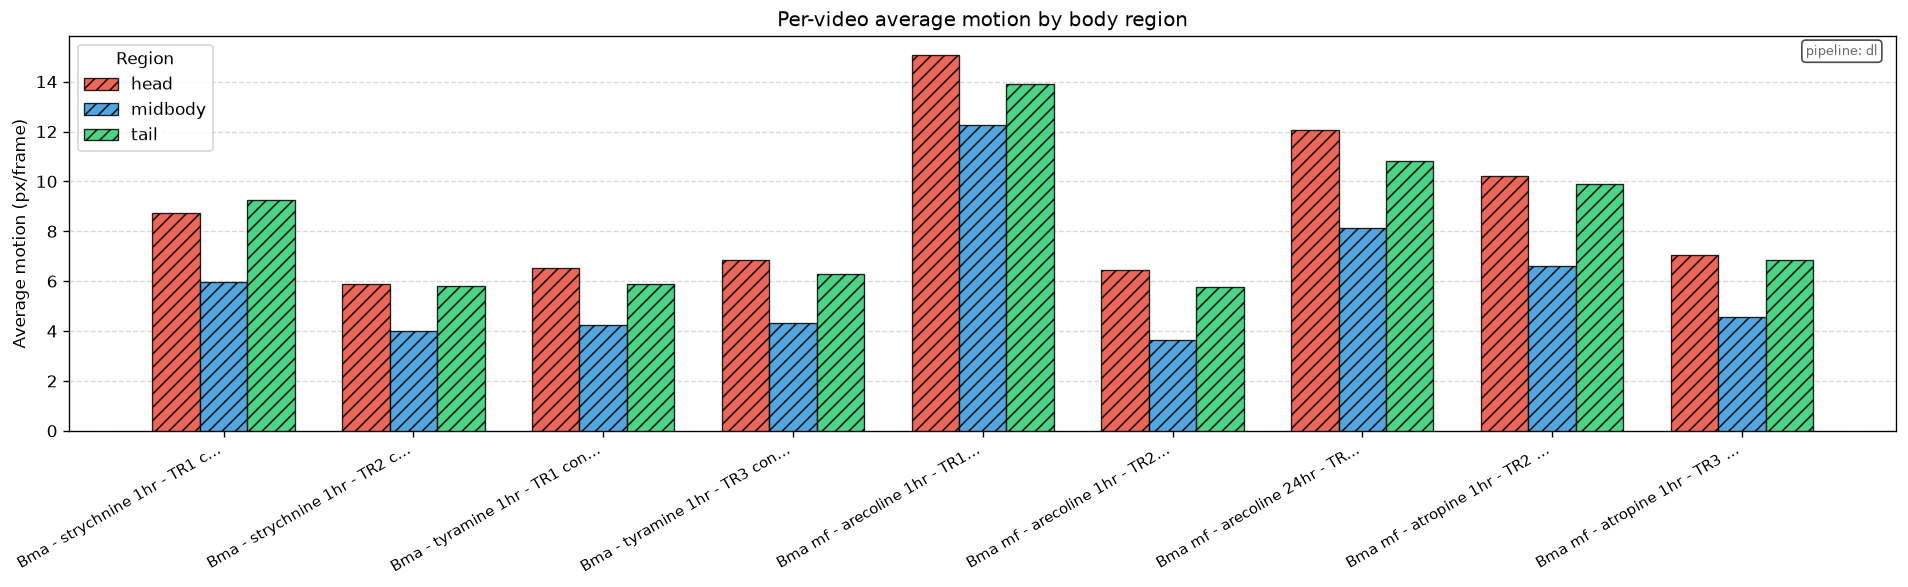

In [9]:
# ── Chart 1: Per-video grouped bar (avg head / midbody / tail) ────────────────
# Bars are coloured by body region.
# When both classical and YOLO jobs exist, a hatch pattern marks the YOLO bars
# and a second legend explains the distinction.

videos    = per_video_df["video"].tolist()
pipelines = per_video_df["pipeline"].tolist()
n         = len(videos)
regions   = ["head", "midbody", "tail"]
width     = 0.25
x         = np.arange(n)

fig, ax = plt.subplots(figsize=(max(8, n * 1.8), 5))

first_bar: dict = {}
for i, region in enumerate(regions):
    bars = ax.bar(
        x + (i - 1) * width,
        per_video_df[f"avg_{region}"],
        width=width,
        color=REGION_COLORS[region],
        alpha=0.85,
        zorder=3,
    )
    first_bar[region] = bars[0]
    for bar, pl in zip(bars, pipelines):
        bar.set_hatch(PIPELINE_HATCHES.get(pl, ""))
        bar.set_edgecolor(PIPELINE_EDGE.get(pl, "white"))
        bar.set_linewidth(0.8)

ax.set_xticks(x)
ax.set_xticklabels([_shorten(v) for v in videos], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Average motion (px/frame)")
ax.set_title("Per-video average motion by body region")
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)

region_legend = ax.legend(
    handles=list(first_bar.values()),
    labels=list(first_bar.keys()),
    title="Region", loc="upper left",
)

unique_pipelines = sorted(set(pipelines))
if len(unique_pipelines) > 1:
    pipeline_patches = [
        mpatches.Patch(
            facecolor="grey",
            hatch=PIPELINE_HATCHES.get(pl, ""),
            edgecolor=PIPELINE_EDGE.get(pl, "white"),
            label=f"{pl} pipeline",
        )
        for pl in unique_pipelines
    ]
    ax.add_artist(region_legend)
    ax.legend(handles=pipeline_patches, title="Pipeline", loc="upper right")
else:
    ax.text(
        0.99, 0.98, f"pipeline: {unique_pipelines[0]}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color="dimgrey",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )

plt.tight_layout()
plt.savefig(SAVE_DIR / "chart1_per_video_bar.png", dpi=150, bbox_inches="tight")
plt.show()

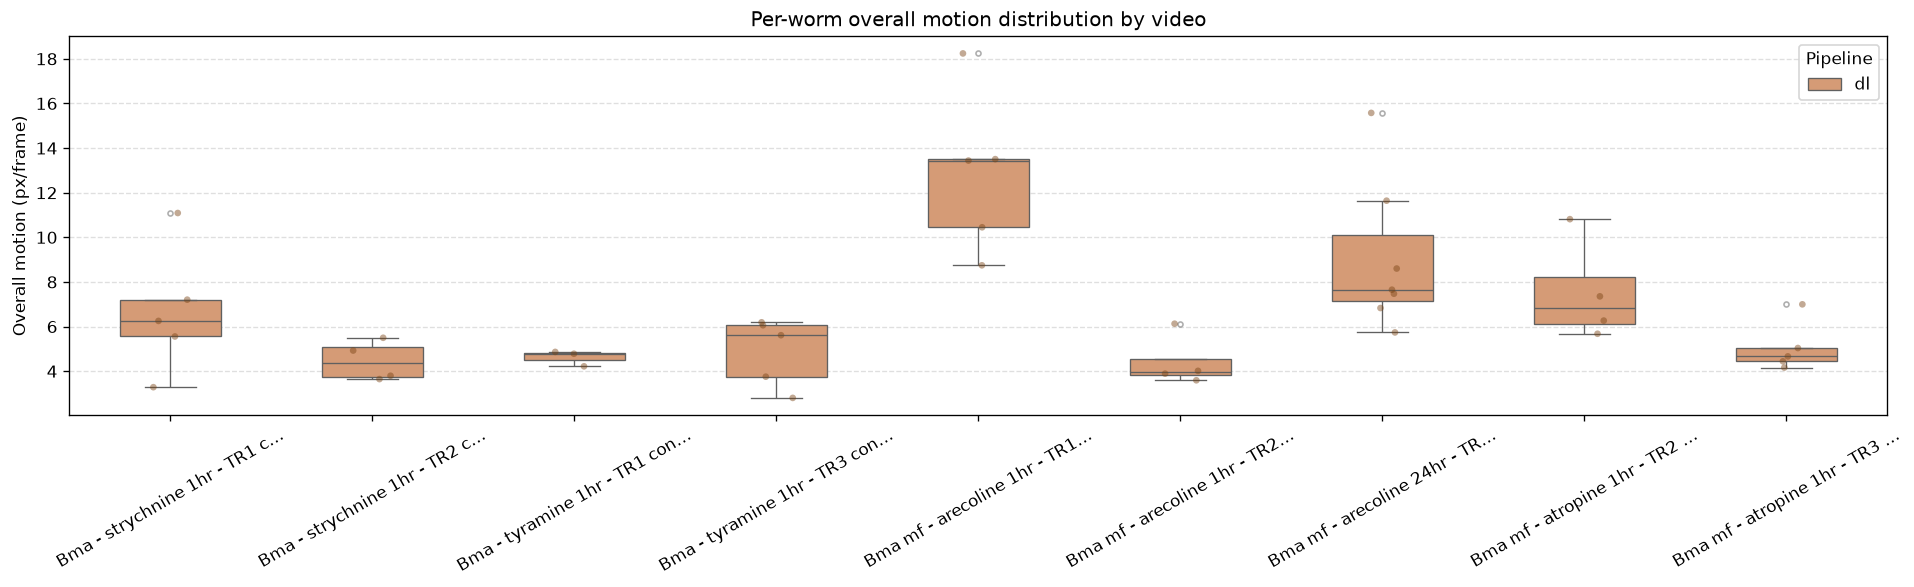

In [10]:
# ── Chart 2: Per-worm overall motion distribution by video (box + strip) ──────
# hue = pipeline so classical and YOLO worms are always colour-coded separately.

pw_plot = per_worm_df.copy()
pw_plot["video_short"] = pw_plot["video"].apply(_shorten)

# Stable ordering: same order as per_video_df
vid_order = [_shorten(v) for v in per_video_df["video"].tolist()]

fig, ax = plt.subplots(figsize=(max(8, n * 1.8), 5))

sns.boxplot(
    data=pw_plot,
    x="video_short", y="overall",
    hue="pipeline",
    order=vid_order,
    palette=PIPELINE_PALETTE,
    width=0.5, linewidth=0.8,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.5},
    ax=ax,
)
sns.stripplot(
    data=pw_plot,
    x="video_short", y="overall",
    hue="pipeline",
    order=vid_order,
    palette={"classical": "#1a5276", "dl": "#784212"},
    dodge=True, size=4, alpha=0.45, jitter=True,
    ax=ax, legend=False,
)

ax.set_xlabel("")
ax.set_ylabel("Overall motion (px/frame)")
ax.set_title("Per-worm overall motion distribution by video")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Deduplicate legend (boxplot may add duplicate handles)
handles, labels = ax.get_legend_handles_labels()
seen_lbl: dict = {}
for h, l in zip(handles, labels):
    if l not in seen_lbl:
        seen_lbl[l] = h
ax.legend(seen_lbl.values(), seen_lbl.keys(), title="Pipeline")

plt.tight_layout()
plt.savefig(SAVE_DIR / "chart2_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Drill-down video : Bma mf - arecoline 24hr - TR2 control.mp4
To change it, set DRILL_DOWN_VIDEO = '<exact video name>' and re-run this cell.


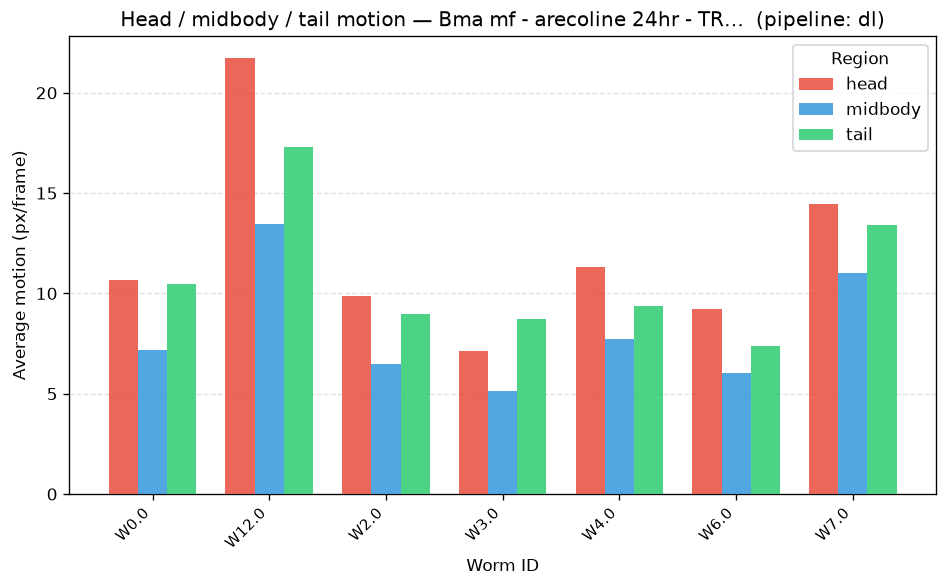

In [11]:
# ── Chart 3: Single-video drill-down (head / midbody / tail per worm) ─────────
# Default: the video with the most worms.  Change DRILL_DOWN_VIDEO to any value
# from combined_per_worm.csv to pivot to a different video.

DRILL_DOWN_VIDEO = per_worm_df.groupby("video")["worm_id"].count().idxmax()

print(f"Drill-down video : {DRILL_DOWN_VIDEO}")
print("To change it, set DRILL_DOWN_VIDEO = '<exact video name>' and re-run this cell.")

dv = per_worm_df[per_worm_df["video"] == DRILL_DOWN_VIDEO].copy()
dv["worm_label"] = "W" + dv["worm_id"].astype(str)

# Sort worm labels numerically where possible
worm_order = sorted(
    dv["worm_label"].unique(),
    key=lambda s: int(s[1:]) if s[1:].isdigit() else s,
)

n_worms = len(worm_order)
regions = ["head", "midbody", "tail"]
width   = 0.25
xi      = np.arange(n_worms)

fig, ax = plt.subplots(figsize=(max(8, n_worms * 1.0), 5))

for i, region in enumerate(regions):
    vals = [
        float(dv.loc[dv["worm_label"] == wl, region].iloc[0])
        for wl in worm_order
    ]
    ax.bar(
        xi + (i - 1) * width,
        vals,
        width=width,
        color=REGION_COLORS[region],
        alpha=0.85,
        label=region,
        zorder=3,
    )

ax.set_xticks(xi)
ax.set_xticklabels(worm_order, rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Worm ID")
ax.set_ylabel("Average motion (px/frame)")
pl_label   = dv["pipeline"].iloc[0]
short_name = _shorten(DRILL_DOWN_VIDEO)
ax.set_title(f"Head / midbody / tail motion — {short_name}  (pipeline: {pl_label})")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(title="Region")

plt.tight_layout()
plt.savefig(SAVE_DIR / "chart3_drill_down.png", dpi=150, bbox_inches="tight")
plt.show()

## Analysis B — Condition-based grouping

Filter videos by keyword, inspect exactly which videos are pooled, and compare
motion across conditions.

| Cell | Purpose |
|------|---------|
| B-1  | Keyword filter + membership audit (stand-in for a UI select/deselect box) |
| B-2  | Summary statistics for the matched group |
| B-3  | Multi-group comparison: define two or more conditions and compare head/midbody/tail side-by-side |

**Pipeline safety**: stats and charts always split by pipeline — classical and
DL/YOLO worms are never blended into one mean.

In [12]:
# ── B-1: Keyword filter + membership audit ────────────────────────────────────
#
# Set `keyword` to any space-separated combination of tokens.
# A video is matched when its filename contains ALL tokens (case-insensitive).
# Token order and adjacency don't matter:
#   "atropine tr2"  matches  "Bma mf - atropine 1hr - TR2 control.mp4"
# Empty string matches every video.
#
# This cell is the stand-in for a UI text box + select/deselect confirmation.
# The printed table below is the membership audit — review it before drawing
# conclusions from B-2 / B-3.

keyword = "atropine tr3"   # ← edit this


def _tokens(kw: str) -> list:
    return kw.lower().split() if kw.strip() else []


def matches_keyword(filename: str, toks: list) -> bool:
    """True iff the lowercased filename contains every token."""
    fname = filename.lower()
    return all(tok in fname for tok in toks)


_toks = _tokens(keyword)
_all_videos = per_worm_df["video"].unique()
matched_videos = sorted(v for v in _all_videos if matches_keyword(v, _toks))

print(f"Keyword  : {keyword!r}")
print(f"Tokens   : {_toks if _toks else '(none — matching all videos)'}")
print(f"Matched  : {len(matched_videos)} of {len(_all_videos)} video(s)")
print()
print(f"  {'Video':55s}  Pipeline  Worms")
print(f"  {'-'*72}")

for v in matched_videos:
    subset = per_worm_df[per_worm_df["video"] == v]
    pl = subset["pipeline"].iloc[0]
    n  = len(subset)
    print(f"  {v[:55]:55s}  {pl:8s}  {n}")

if not matched_videos:
    print("  (no videos matched)")

_matched_pipelines = {
    v: per_worm_df.loc[per_worm_df["video"] == v, "pipeline"].iloc[0]
    for v in matched_videos
}
_unique_pls = set(_matched_pipelines.values())
if len(_unique_pls) > 1:
    print(f"\n  ⚠  MIXED PIPELINES detected: {sorted(_unique_pls)}")
    print("     B-2 stats and B-3 chart are reported per pipeline — never blended.")

Keyword  : 'atropine tr3'
Tokens   : ['atropine', 'tr3']
Matched  : 1 of 9 video(s)

  Video                                                    Pipeline  Worms
  ------------------------------------------------------------------------
  Bma mf - atropine 1hr - TR3 control.mp4                  dl        5


In [13]:
# ── B-2: Group statistics ─────────────────────────────────────────────────────
# Pools all worms from the videos matched in B-1.
# Stats are always reported per pipeline — never blended.

assert matched_videos, "No videos matched — update `keyword` in B-1 and re-run."

_group_worms = per_worm_df[per_worm_df["video"].isin(matched_videos)].copy()

print(f"Group: {keyword!r}")
print(f"  Videos : {len(matched_videos)}")
print(f"  Worms  : {len(_group_worms)}")
print()

_header = f"  {'Metric':10s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}"
_sep    = f"  {'-'*56}"

for pl, pl_df in _group_worms.groupby("pipeline"):
    print(f"Pipeline: {pl}  ({len(pl_df)} worms across {pl_df['video'].nunique()} video(s))")
    print(_header)
    print(_sep)
    for col, label in [("head", "head"), ("midbody", "midbody"), ("tail", "tail"), ("overall", "overall")]:
        print(
            f"  {label:10s}  "
            f"{pl_df[col].mean():10.4f}  "
            f"{pl_df[col].std():10.4f}  "
            f"{pl_df[col].min():10.4f}  "
            f"{pl_df[col].max():10.4f}"
        )
    print()

Group: 'atropine tr3'
  Videos : 1
  Worms  : 5

Pipeline: dl  (5 worms across 1 video(s))
  Metric            Mean         Std         Min         Max
  --------------------------------------------------------
  head            7.0425      1.6721      5.6120      9.6174
  midbody         4.5758      1.0587      3.5389      6.2796
  tail            6.8297      1.9899      4.6162      9.9466
  overall         5.0620      1.1285      4.1642      6.9977



Comparison group statistics (mean ± std across worms, raw px/frame):



,group,pipeline,n_videos,n_worms,head µ,mid µ,tail µ,head σ,mid σ,tail σ
0,atropine,dl,2,9,8.460400,5.470700,8.192500,2.964900,1.688400,3.008500
1,strychnine,dl,2,9,7.453300,5.080200,7.729000,2.758200,2.204800,4.069900
2,tyramine,dl,2,8,6.732400,4.293800,6.129100,1.821300,1.090200,1.892000
3,arecoline,dl,3,16,11.595500,8.310200,10.523600,5.254500,4.364600,4.009500


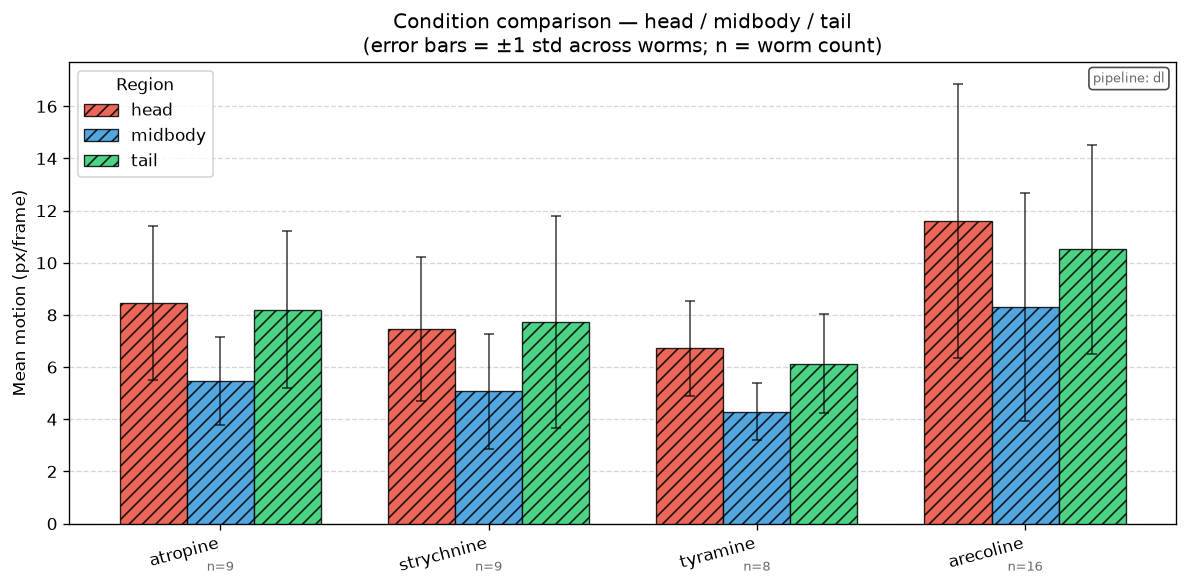

In [14]:
# ── B-3: Multi-group comparison ───────────────────────────────────────────────
#
# Define two or more named groups; each entry is a keyword string that follows
# the same token-matching logic as B-1.  An empty string ("") matches all videos.
#
# Examples:
#   COMPARISON_GROUPS = {"atropine": "atropine", "strychnine": "strychnine"}
#   COMPARISON_GROUPS = {"treated": "atropine", "all": ""}
#
# When a keyword matches videos from more than one pipeline, the group is split
# into separate (group, pipeline) rows in the table and chart — they are never
# blended.  A mixed-pipeline group shows as two x-ticks: "label (dl)" and
# "label (classical)".

COMPARISON_GROUPS = {
    "atropine"  : "atropine",
    "strychnine": "strychnine",
    "tyramine"  : "tyramine",
    "arecoline" : "arecoline",
}

# ── Build per-(group × pipeline) statistics ───────────────────────────────────
_cmp_rows = []
for group_label, kw in COMPARISON_GROUPS.items():
    toks    = _tokens(kw)
    matched = [v for v in per_worm_df["video"].unique() if matches_keyword(v, toks)]
    subset  = per_worm_df[per_worm_df["video"].isin(matched)]

    if subset.empty:
        print(f"[warn] group {group_label!r} (keyword={kw!r}) matched no videos — skipped")
        continue

    for pl, pl_df in subset.groupby("pipeline"):
        _cmp_rows.append({
            "group"       : group_label,
            "pipeline"    : pl,
            "n_videos"    : pl_df["video"].nunique(),
            "n_worms"     : len(pl_df),
            "head_mean"   : pl_df["head"].mean(),
            "midbody_mean": pl_df["midbody"].mean(),
            "tail_mean"   : pl_df["tail"].mean(),
            "head_std"    : pl_df["head"].std(),
            "midbody_std" : pl_df["midbody"].std(),
            "tail_std"    : pl_df["tail"].std(),
        })

assert _cmp_rows, "No groups produced any data — check COMPARISON_GROUPS keywords."
_cmp = pd.DataFrame(_cmp_rows)

# ── Print summary table ───────────────────────────────────────────────────────
print("Comparison group statistics (mean ± std across worms, raw px/frame):\n")
display(
    _cmp[["group", "pipeline", "n_videos", "n_worms",
          "head_mean", "midbody_mean", "tail_mean",
          "head_std",  "midbody_std",  "tail_std"]]
    .rename(columns={
        "head_mean": "head µ", "midbody_mean": "mid µ", "tail_mean": "tail µ",
        "head_std" : "head σ", "midbody_std" : "mid σ", "tail_std" : "tail σ",
    })
    .round(4)
)

# ── Build x-tick labels — split (group, pipeline) when pipelines mix ──────────
_multi_pl_groups = (
    _cmp.groupby("group")["pipeline"]
    .nunique()
    .loc[lambda s: s > 1]
    .index.tolist()
)

_cmp["x_label"] = _cmp.apply(
    lambda r: f"{r['group']} ({r['pipeline']})" if r["group"] in _multi_pl_groups else r["group"],
    axis=1,
)

# ── Chart ─────────────────────────────────────────────────────────────────────
_regions = ["head", "midbody", "tail"]
_width   = 0.25
_x       = np.arange(len(_cmp))

fig, ax = plt.subplots(figsize=(max(8, len(_cmp) * 2.5), 5))

_first_bar: dict = {}
for i, region in enumerate(_regions):
    col_mean = f"{region}_mean"
    col_std  = f"{region}_std"
    bars = ax.bar(
        _x + (i - 1) * _width,
        _cmp[col_mean],
        _width,
        yerr=_cmp[col_std],
        error_kw={"linewidth": 1.0, "capsize": 3, "alpha": 0.7},
        color=REGION_COLORS[region],
        alpha=0.85,
        zorder=3,
    )
    _first_bar[region] = bars[0]
    for bar, pl in zip(bars, _cmp["pipeline"]):
        bar.set_hatch(PIPELINE_HATCHES.get(pl, ""))
        bar.set_edgecolor(PIPELINE_EDGE.get(pl, "white"))
        bar.set_linewidth(0.8)

# Annotate each x-tick with worm count
for xi, (_, row) in zip(_x, _cmp.iterrows()):
    ax.text(xi, -0.08, f"n={row['n_worms']}", ha="center", va="top",
            fontsize=8, color="dimgrey", transform=ax.get_xaxis_transform())

ax.set_xticks(_x)
ax.set_xticklabels(_cmp["x_label"], rotation=15, ha="right", fontsize=10)
ax.set_ylabel("Mean motion (px/frame)")
ax.set_title("Condition comparison — head / midbody / tail\n(error bars = ±1 std across worms; n = worm count)")
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)

_region_legend = ax.legend(
    handles=list(_first_bar.values()),
    labels=list(_first_bar.keys()),
    title="Region", loc="upper left",
)

_unique_pls_cmp = sorted(_cmp["pipeline"].unique())
if len(_unique_pls_cmp) > 1:
    _pl_patches = [
        mpatches.Patch(
            facecolor="grey",
            hatch=PIPELINE_HATCHES.get(pl, ""),
            edgecolor=PIPELINE_EDGE.get(pl, "white"),
            label=f"{pl} pipeline",
        )
        for pl in _unique_pls_cmp
    ]
    ax.add_artist(_region_legend)
    ax.legend(handles=_pl_patches, title="Pipeline", loc="upper right")
else:
    ax.text(
        0.99, 0.98, f"pipeline: {_unique_pls_cmp[0]}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color="dimgrey",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )

plt.tight_layout()
plt.savefig(SAVE_DIR / "chartB_comparison.png", dpi=150, bbox_inches="tight")
plt.show()